In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    PolynomialFeatures,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
    QuantileTransformer,
)

from src.config import DADOS_LIMPOS
from src.auxiliares import dataframe_coeficientes
from src.graficos import (
    plot_coeficientes,
    plot_comparar_metricas_modelos,
    plot_residuos_estimador,
)
from src.models import (
    organiza_resultados,
    treinar_e_validar_modelo_regressao,
    grid_search_cv_regressor,
)

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_cat,room_per_households,population_per_households,bedrooms_per_room
0,-122.23,37.88,41,880,129,322,126,8.3252,452600,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.26,37.84,42,2555,665,1206,595,2.0804,226700,NEAR BAY,2,4.294118,2.026891,0.260274
3,-122.26,37.85,50,1120,283,697,264,2.1250,140000,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.26,37.84,50,2239,455,990,419,1.9911,158700,NEAR BAY,2,5.343675,2.362768,0.203216


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17564 entries, 0 to 17563
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   longitude                  17564 non-null  float64 
 1   latitude                   17564 non-null  float64 
 2   housing_median_age         17564 non-null  int8    
 3   total_rooms                17564 non-null  int16   
 4   total_bedrooms             17564 non-null  int16   
 5   population                 17564 non-null  int16   
 6   households                 17564 non-null  int16   
 7   median_income              17564 non-null  float64 
 8   median_house_value         17564 non-null  int32   
 9   ocean_proximity            17564 non-null  category
 10  median_income_cat          17564 non-null  int64   
 11  room_per_households        17564 non-null  float64 
 12  population_per_households  17564 non-null  float64 
 13  bedrooms_per_room          1756

In [4]:
coluna_target = ["median_house_value"]

coluna_one_hot_encoder = ["ocean_proximity"]

coluna_ordinal_encoder = ["median_income_cat"]

In [5]:
preprocessamento = ColumnTransformer(
    transformers=[
        ("ordinal_encoder", OrdinalEncoder(categories="auto"), coluna_ordinal_encoder),
        ("one_hot", OneHotEncoder(drop="first"), coluna_one_hot_encoder)
    ],
    remainder="passthrough",
)

In [6]:
X = df.drop(columns=coluna_target)
y = df[coluna_target]

In [7]:
target_transformer = PowerTransformer()

regressors = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer": None,
    },

    "LinearRegressor": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": None,
    },

    "LinearRegressor_target": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": target_transformer,
    },
    
}

In [8]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(X, y, **regressor)
    for nome_modelo, regressor in regressors.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.008961,0.006927,-0.000081,-77516.042766,-96239.705692,0.015888
1,DummyRegressor,0.004826,0.006397,-0.000146,-75787.787194,-95217.629397,0.011223
2,DummyRegressor,0.005374,0.006675,-0.001737,-76753.598961,-96253.253947,0.012049
3,DummyRegressor,0.004255,0.005089,-0.000101,-76837.804811,-95983.885799,0.009344
4,DummyRegressor,0.004798,0.006767,-0.000114,-76617.245449,-96182.764729,0.011565
5,LinearRegressor,0.050482,0.014918,0.682162,-39855.691222,-54254.958862,0.0654
6,LinearRegressor,0.036123,0.016182,0.66999,-40272.5658,-54695.230987,0.052305
7,LinearRegressor,0.034847,0.014904,0.649247,-42178.059695,-56955.987903,0.04975
8,LinearRegressor,0.033894,0.015531,0.669873,-40806.492334,-55146.319086,0.049425
9,LinearRegressor,0.036086,0.019775,0.669023,-40788.497206,-55331.350878,0.055861


In [9]:
df_resultados.groupby("model").mean()

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
DummyRegressor,0.005643,0.006371,-0.000436,-76702.495836,-95975.447913,0.012014
LinearRegressor,0.038286,0.016262,0.668059,-40780.261251,-55276.769543,0.054548
LinearRegressor_target,0.080407,0.018054,0.671185,-38909.259604,-55011.704639,0.098461


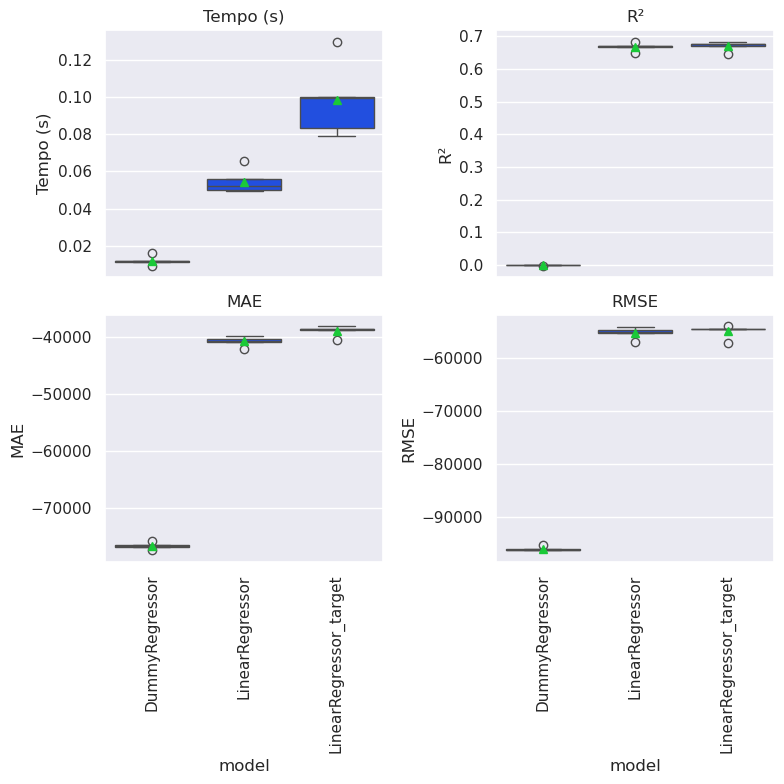

In [10]:
plot_comparar_metricas_modelos(df_resultados)

In [11]:
param_grid = {
    "transformer": [None, PowerTransformer(), QuantileTransformer(output_distribution="normal")]
}

In [12]:
grid_search = grid_search_cv_regressor(
    regressor=LinearRegression(),
    preprocessor=preprocessamento,
    target_transformer=target_transformer,
    param_grid=param_grid
)

grid_search

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(remainder='passthrough',
                                                                                               transformers=[('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat']),
                                                                                                             ('one_hot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity'])])),
                                                                            ('reg',
                                                                             LinearRegression())]),
                                                  transformer=PowerTransformer()),
             n_jobs=-1,
             param_grid={'transformer': [None, PowerTransformer(),
                                         QuantileTransformer(output_distribution='normal')]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [13]:
grid_search.fit(X, y)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(remainder='passthrough',
                                                                                               transformers=[('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat']),
                                                                                                             ('one_hot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity'])])),
                                                                            ('reg',
                                                                             LinearRegression())]),
                                                  transformer=PowerTransformer()),
             n_jobs=-1,
             param_grid={'transformer': [None, PowerTransformer(),
                                         QuantileTransformer(output_distribution='normal')]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [14]:
grid_search.best_params_

{'transformer': QuantileTransformer(output_distribution='normal')}

In [15]:
grid_search.best_score_

-54420.82545383929

In [16]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_.regressor_["reg"].coef_,
    grid_search.best_estimator_.regressor_["preprocessor"].get_feature_names_out()
)

coefs

,coeficiente
one_hot__ocean_proximity_INLAND,-0.455662
remainder__longitude,-0.296072
remainder__latitude,-0.289339
remainder__population_per_households,-0.280772
one_hot__ocean_proximity_NEAR BAY,-0.203036
one_hot__ocean_proximity_NEAR OCEAN,-0.058903
remainder__total_bedrooms,-0.000231
remainder__total_rooms,-0.000060
remainder__population,-0.000037
remainder__households,0.000866


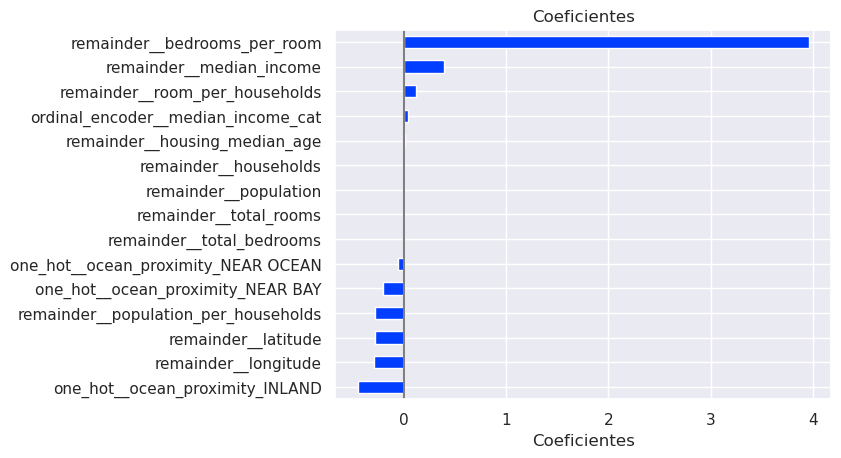

In [17]:
plot_coeficientes(coefs)

In [18]:
regressors = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer": None,
    },

    "LinearRegressor": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": None,
    },

    "LinearRegressor_target_power": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": target_transformer,
    },

    "LinearRegressor_target_quantile": {
        "preprocessor": grid_search.best_estimator_.regressor_["preprocessor"],
        "regressor": grid_search.best_estimator_.regressor_["reg"],
        "target_transformer": grid_search.best_estimator_.transformer_,
    },
    
}

In [19]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(X, y, **regressor)
    for nome_modelo, regressor in regressors.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.00772,0.007902,-0.000081,-77516.042766,-96239.705692,0.015621
1,DummyRegressor,0.003326,0.004996,-0.000146,-75787.787194,-95217.629397,0.008322
2,DummyRegressor,0.004288,0.005151,-0.001737,-76753.598961,-96253.253947,0.009439
3,DummyRegressor,0.003528,0.003602,-0.000101,-76837.804811,-95983.885799,0.00713
4,DummyRegressor,0.002987,0.003105,-0.000114,-76617.245449,-96182.764729,0.006092
5,LinearRegressor,0.026973,0.016918,0.682162,-39855.691222,-54254.958862,0.043891
6,LinearRegressor,0.03681,0.029763,0.66999,-40272.5658,-54695.230987,0.066573
7,LinearRegressor,0.047967,0.027864,0.649247,-42178.059695,-56955.987903,0.075831
8,LinearRegressor,0.049093,0.02929,0.669873,-40806.492334,-55146.319086,0.078383
9,LinearRegressor,0.067224,0.030363,0.669023,-40788.497206,-55331.350878,0.097587


In [20]:
df_resultados.groupby("model").mean()

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
DummyRegressor,0.00437,0.004951,-0.000436,-76702.495836,-95975.447913,0.009321
LinearRegressor,0.045613,0.02684,0.668059,-40780.261251,-55276.769543,0.072453
LinearRegressor_target_power,0.076055,0.020057,0.671185,-38909.259604,-55011.704639,0.096112
LinearRegressor_target_quantile,0.047593,0.017324,0.678174,-38676.138838,-54423.912475,0.064917


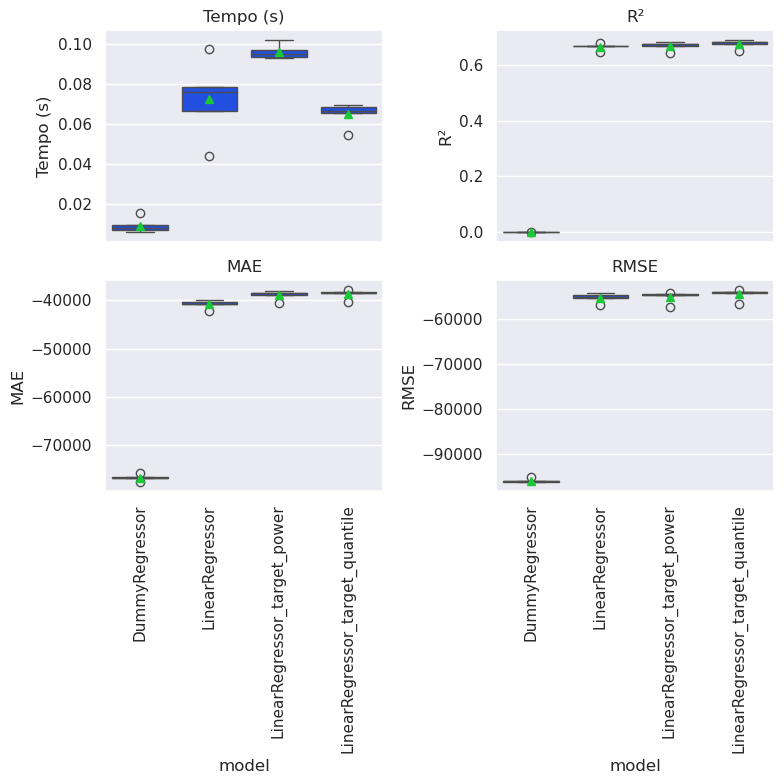

In [21]:
plot_comparar_metricas_modelos(df_resultados)

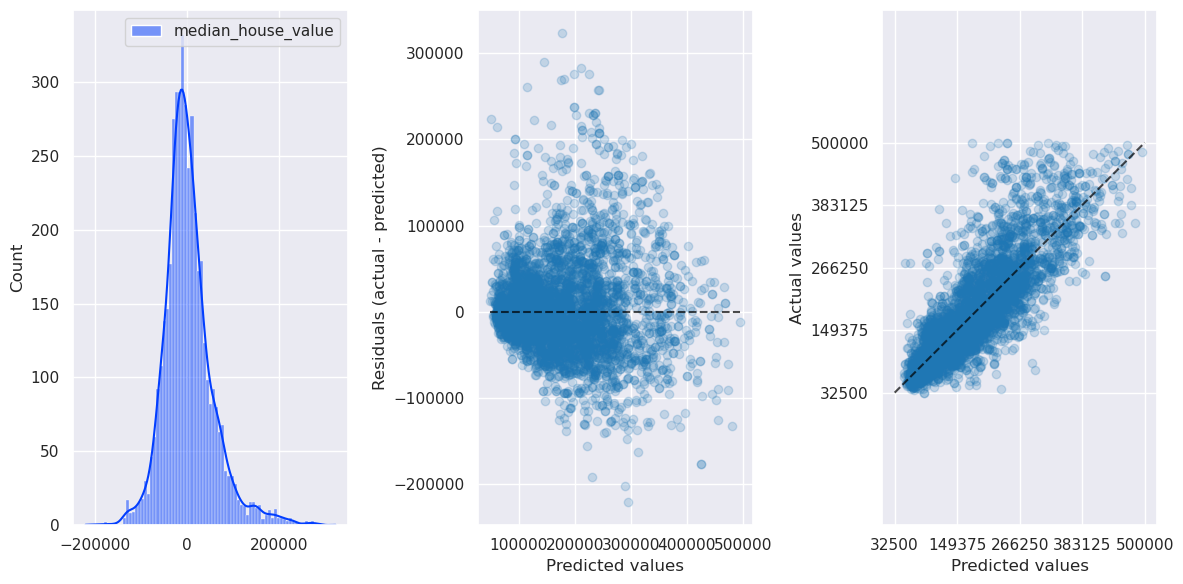

In [22]:
plot_residuos_estimador(grid_search.best_estimator_, X, y)